# CWRU Bearing Dataset — Notebook 2: EDA & Cleaning

**Prerequisite:** Run `01_download.ipynb` first.

This notebook covers:
1. Load all signals using the manifest
2. Data inventory — signal lengths, missing channels
3. Raw signal visualization — all fault types
4. FFT spectra — with BPFI/BPFO/BSF markers
5. OR position comparison — @6 vs @3 vs @12
6. 12k vs 48k signal comparison
7. Statistical feature distributions
8. Severity comparison (7 / 14 / 21 mils)
9. Save cleaned segments → `cwru_segments_12k.npz` and `cwru_segments_48k.npz`

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.io import loadmat
from scipy.fft import fft, fftfreq
from scipy.stats import kurtosis, skew

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
np.random.seed(42)

DATA_DIR   = 'cwru_data'
PLOTS_DIR  = 'eda_plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

# More accurate — compute dynamically from actual RPM
RPM_BY_LOAD = {0: 1797, 1: 1772, 2: 1750, 3: 1730}

def bearing_freqs(rpm):
    shaft_hz = rpm / 60
    return {
        'BPFI': 5.4152 * shaft_hz,   # Inner race
        'BPFO': 3.5848 * shaft_hz,   # Outer race
        'BSF':  4.7135 * shaft_hz,   # Ball spin
        'FTF':  0.39828 * shaft_hz   # Cage
    }

for load, rpm in RPM_BY_LOAD.items():
    f = bearing_freqs(rpm)
    print(f"Load {load}HP ({rpm} RPM): BPFI={f['BPFI']:.1f}  BPFO={f['BPFO']:.1f}  BSF={f['BSF']:.1f}  FTF={f['FTF']:.2f}")

print('Libraries loaded.')

Libraries loaded.


## 1. Load All Signals

In [2]:
df_manifest = pd.read_csv('cwru_manifest.csv')
df_manifest = df_manifest[df_manifest['present'] == True].reset_index(drop=True)
print(f'Loading {len(df_manifest)} signal files...')

def extract_de_signal(fpath):
    """Extract drive-end (DE_time) signal from a CWRU .mat file."""
    mat = loadmat(fpath)
    key = next((k for k in mat if 'DE_time' in k), None)
    if key is None:
        key = next((k for k in mat if not k.startswith('_')), None)
    return mat[key].flatten().astype(np.float32)

records = []
for _, row in df_manifest.iterrows():
    fpath = os.path.join(DATA_DIR, row['filename'])
    sig   = extract_de_signal(fpath)
    records.append({**row.to_dict(), 'signal': sig})

print(f'Loaded {len(records)} records.')
print(f'Sample rates present: {df_manifest["sample_rate"].unique()}')

Loading 116 signal files...
Loaded 116 records.
Sample rates present: [12000 48000]


## 2. Data Inventory

In [3]:
print('=== Data Inventory ===')
print(f'\nTotal signal files : {len(records)}')
print(f'\nFiles by sample rate and fault location:')
print(df_manifest.groupby(['sample_rate','fault_loc']).size().unstack(fill_value=0).to_string())
print(f'\nFiles by severity and fault type (12k only):')
df12 = df_manifest[df_manifest['sample_rate']==12000]
print(df12.groupby(['fault_type','severity']).size().unstack(fill_value=0).to_string())

print(f'\nSignal length stats:')
for rate in [12000, 48000]:
    sigs = [r['signal'] for r in records if r['sample_rate']==rate]
    if sigs:
        lengths = [len(s) for s in sigs]
        print(f'  {rate}k: min={min(lengths):,}  max={max(lengths):,}  mean={int(np.mean(lengths)):,}')

=== Data Inventory ===

Total signal files : 116

Files by sample rate and fault location:
fault_loc    Ball  IR  Normal  OR@12  OR@3  OR@6
sample_rate                                     
12000          16  16       4      8     8    12
48000          12  12       0      8     8    12

Files by severity and fault type (12k only):
severity    0   7   14  21  28
fault_type                    
Ball         0   4   4   4   4
IR           0   4   4   4   4
Normal       4   0   0   0   0
OR           0  12   4  12   0

Signal length stats:
  12000k: min=120,801  max=485,643  mean=140,799
  48000k: min=63,788  max=491,446  mean=413,968


## 3. Raw Signal Visualization — All Fault Types (12k)

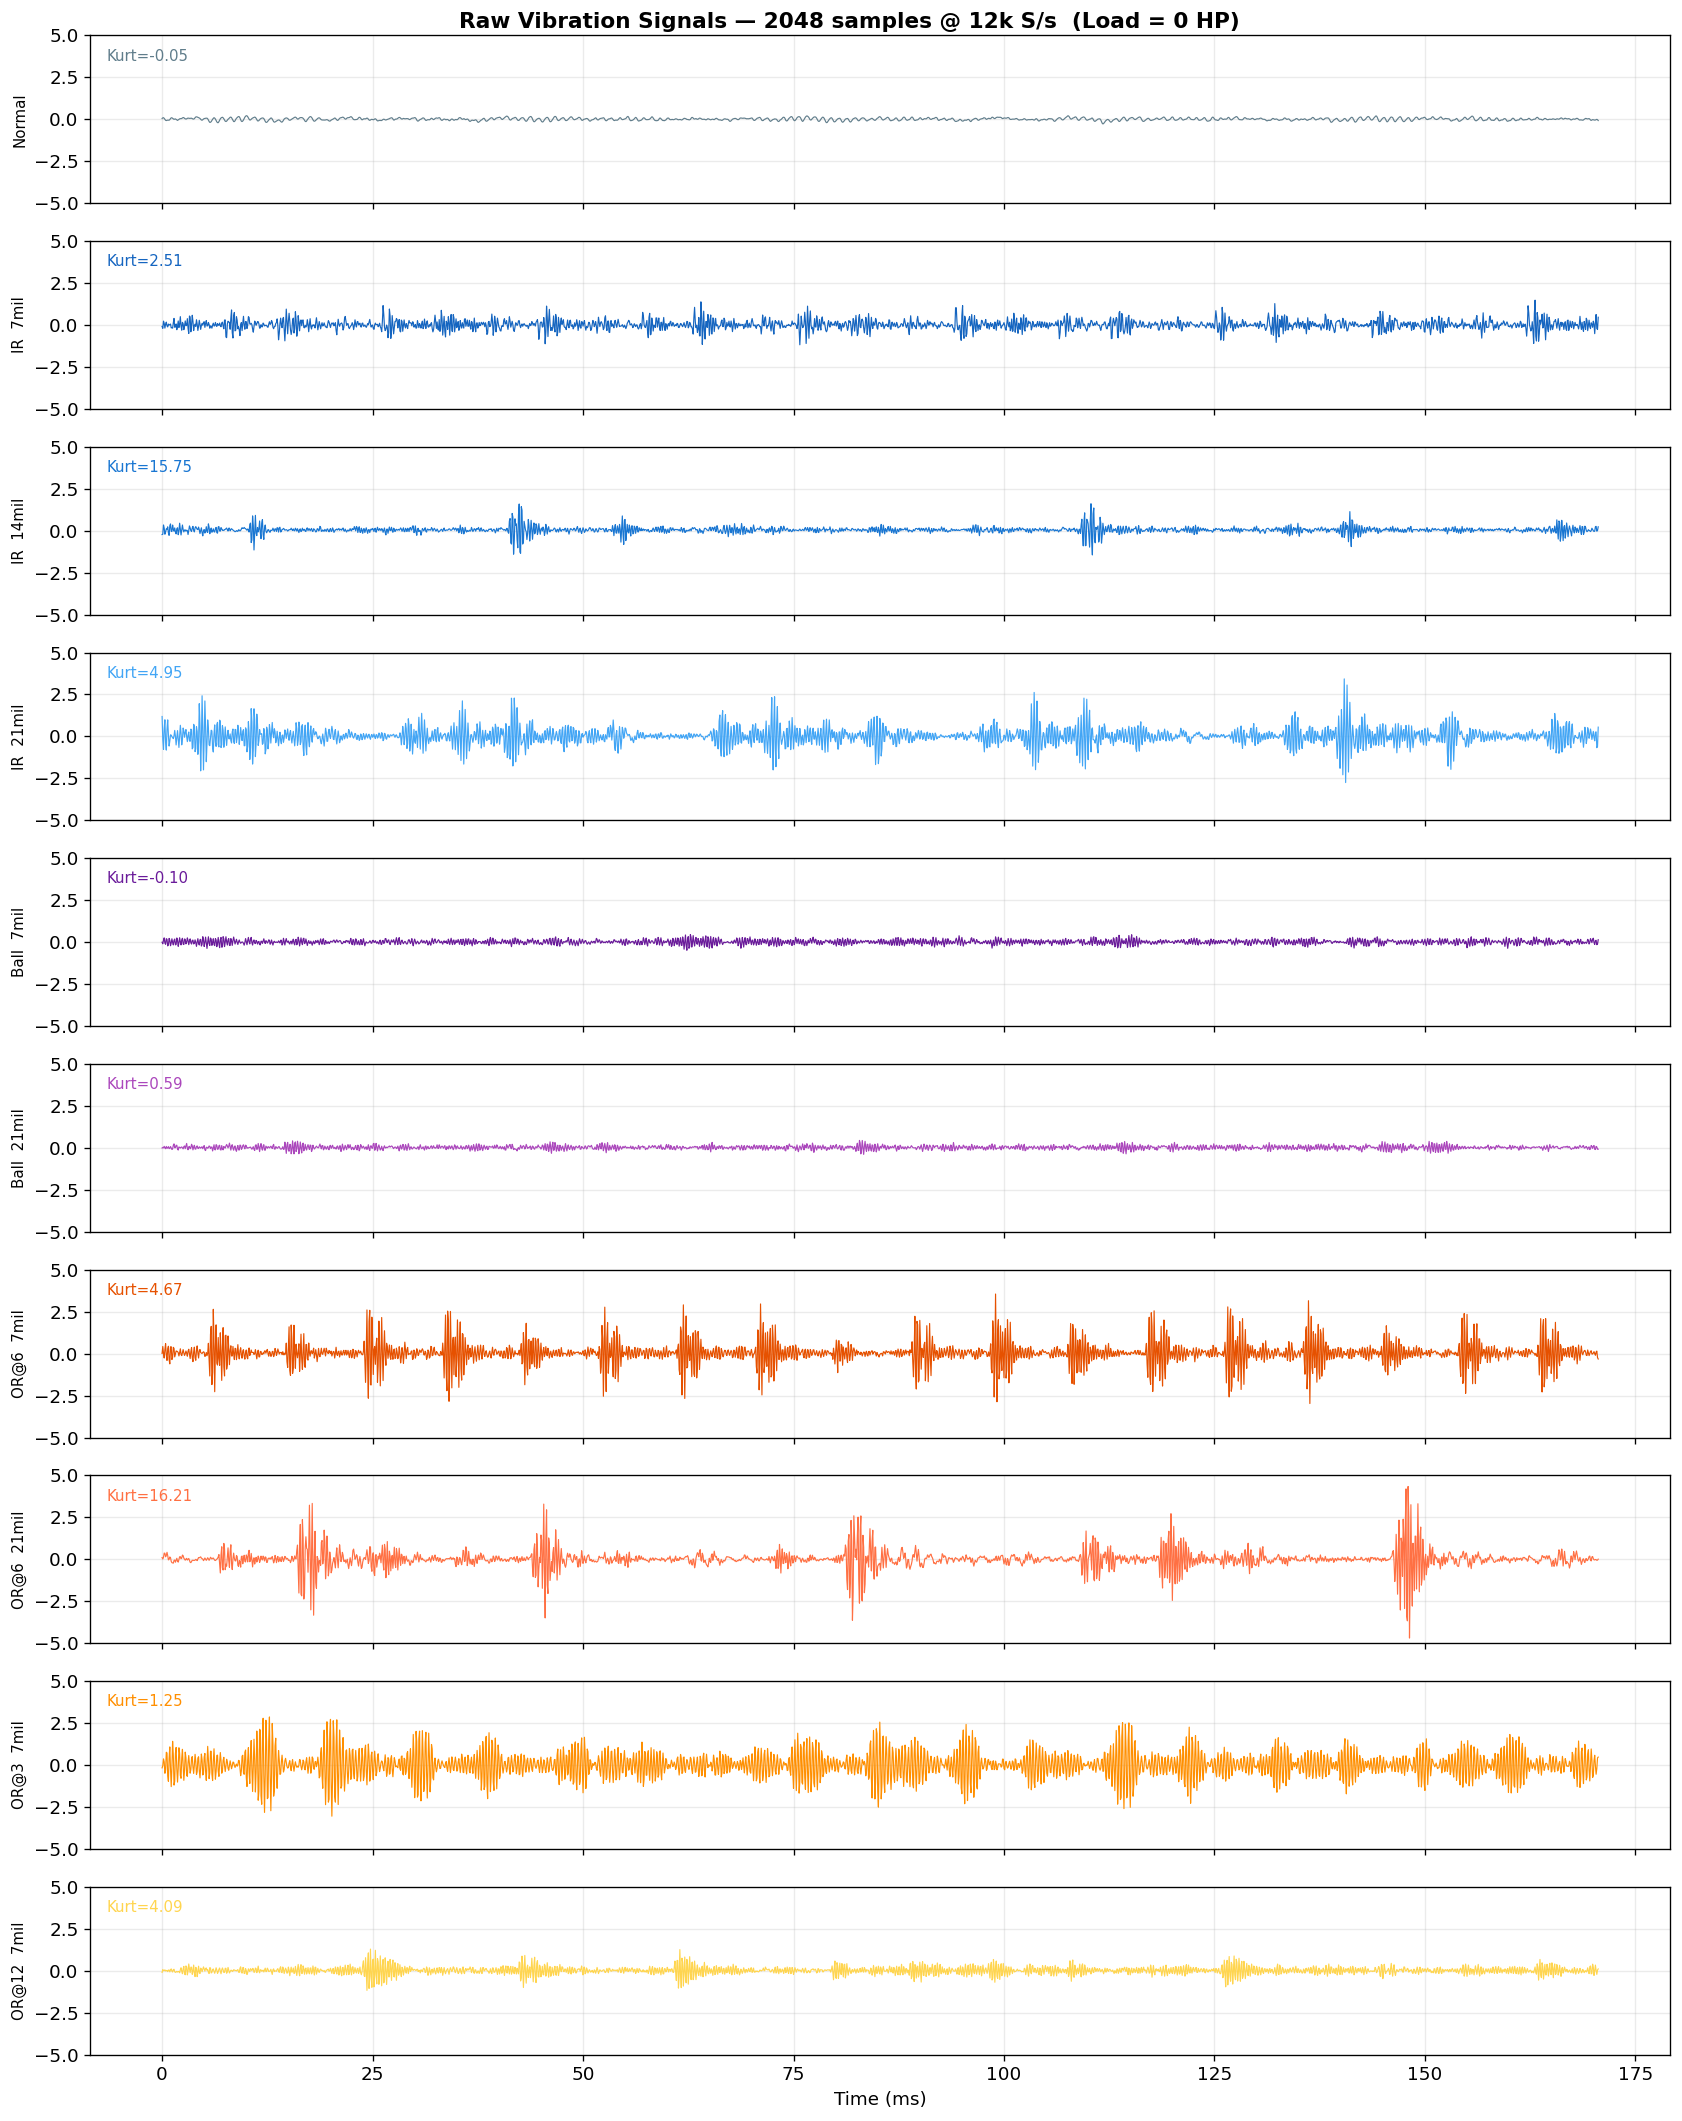

Saved: 01_raw_signals.png


In [4]:
PLOT_CASES = [
    ('Normal', 'Normal', 0,  0, '#607D8B'),
    ('IR',     'IR',     7,  0, '#1565C0'),
    ('IR',     'IR',     14, 0, '#1976D2'),
    ('IR',     'IR',     21, 0, '#42A5F5'),
    ('Ball',   'Ball',   7,  0, '#6A1B9A'),
    ('Ball',   'Ball',   21, 0, '#AB47BC'),
    ('OR',     'OR@6',   7,  0, '#E65100'),
    ('OR',     'OR@6',   21, 0, '#FF7043'),
    ('OR',     'OR@3',   7,  0, '#FF8F00'),
    ('OR',     'OR@12',  7,  0, '#FFD54F'),
]

fig, axes = plt.subplots(len(PLOT_CASES), 1, figsize=(14, 18), sharex=True)
n_samples = 2048
fs = 12000
t = np.arange(n_samples) / fs * 1000

for ax, (ft, fl, sv, ld, col) in zip(axes, PLOT_CASES):
    rec = next((r for r in records
                if r['fault_type']==ft and r['fault_loc']==fl
                and r['severity']==sv and r['load_hp']==ld
                and r['sample_rate']==12000), None)
    label = f'{fl}  {sv}mil' if ft != 'Normal' else 'Normal'
    if rec:
        sig = rec['signal'][:n_samples]
        ax.plot(t, sig, color=col, linewidth=0.7)
        ax.text(0.01, 0.85, f'Kurt={kurtosis(sig):.2f}', transform=ax.transAxes, fontsize=9, color=col)
    ax.set_ylabel(label, fontsize=9)
    ax.set_ylim(-5, 5)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Time (ms)')
fig.suptitle('Raw Vibration Signals — 2048 samples @ 12k S/s  (Load = 0 HP)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/01_raw_signals.png', bbox_inches='tight')
plt.show()
print('Saved: 01_raw_signals.png')

## 4. FFT Spectra with Characteristic Frequency Markers

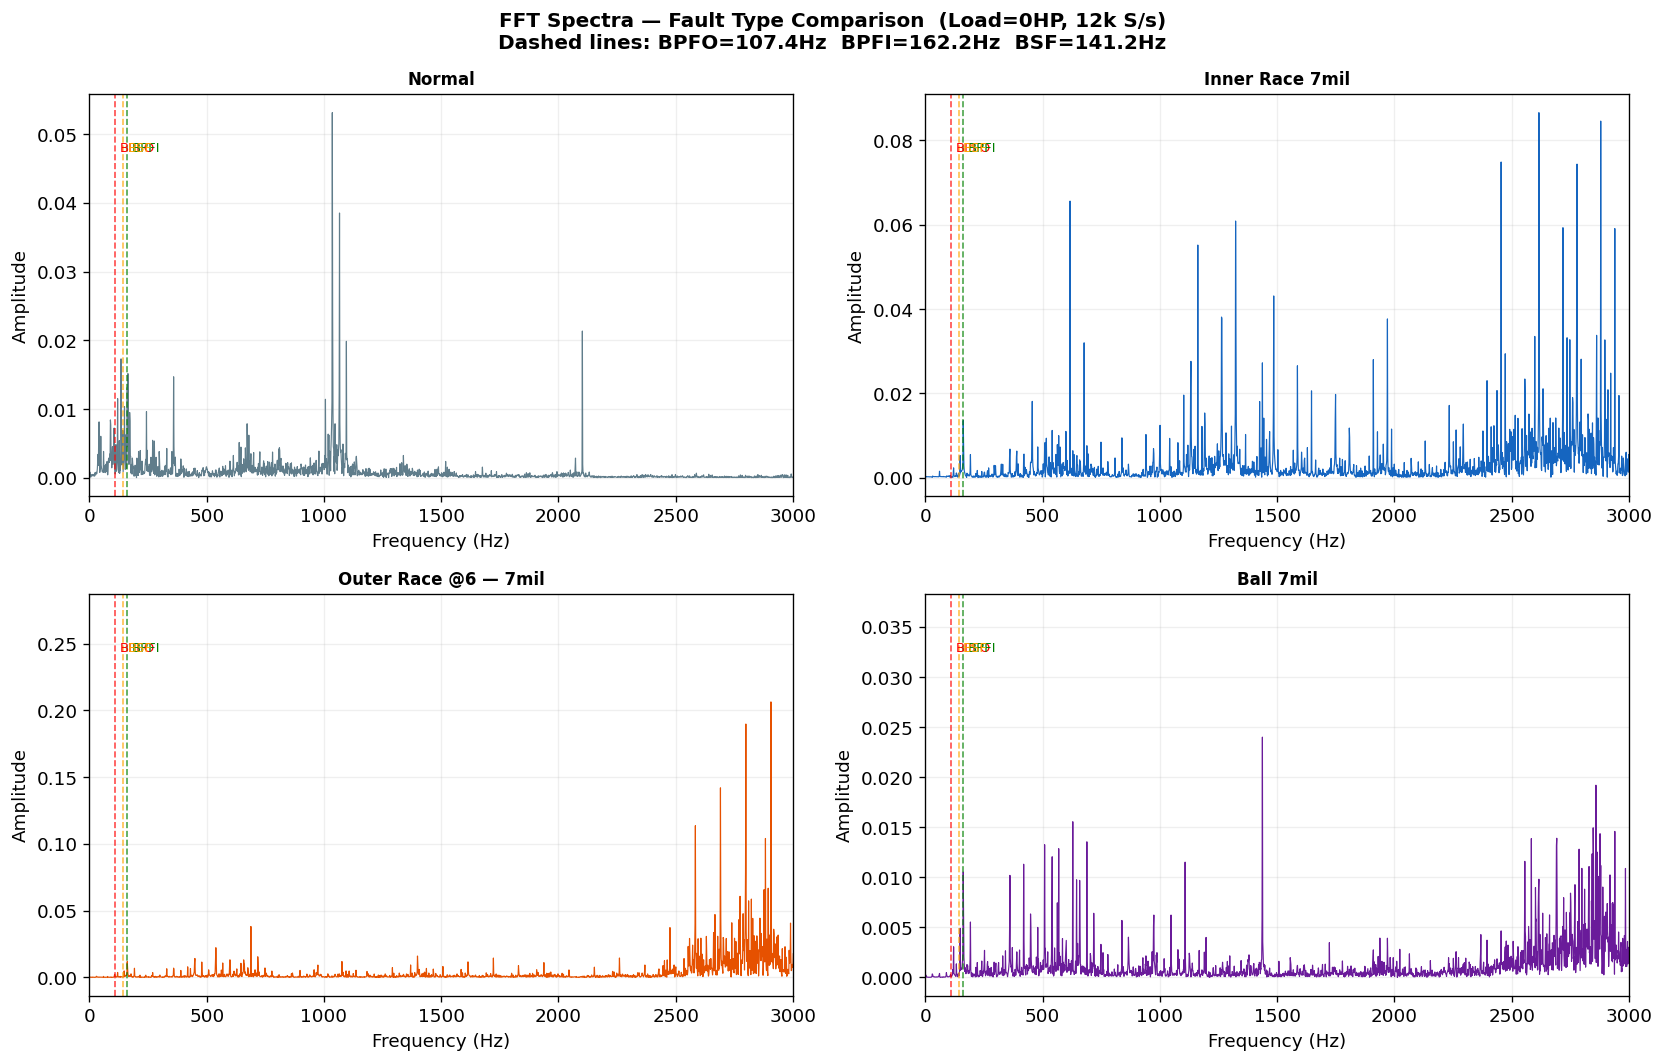

Saved: 02_fft_fault_types.png


In [5]:
def plot_fft(ax, sig, fs, title, color='steelblue', xlim=3000):
    sig = sig - sig.mean()
    N   = len(sig)
    freq = fftfreq(N, 1/fs)[:N//2]
    amp  = (2/N) * np.abs(fft(sig)[:N//2])
    ax.plot(freq, amp, color=color, linewidth=0.7)
    ax.set_xlim(0, xlim)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.2)
    for fval, fname, fcol in [(BPFO,'BPFO','red'),(BPFI,'BPFI','green'),(BSF,'BSF','orange')]:
        ax.axvline(fval, color=fcol, linestyle='--', alpha=0.7, linewidth=1)
        ax.text(fval+20, ax.get_ylim()[1]*0.85, fname, color=fcol, fontsize=8)

# 2x2: Normal, IR_7, OR@6_7, Ball_7
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
cases = [
    ('Normal','Normal', 0, 0, '#607D8B', 'Normal'),
    ('IR',    'IR',     7, 0, '#1565C0', 'Inner Race 7mil'),
    ('OR',    'OR@6',   7, 0, '#E65100', 'Outer Race @6 — 7mil'),
    ('Ball',  'Ball',   7, 0, '#6A1B9A', 'Ball 7mil'),
]
for ax, (ft, fl, sv, ld, col, lbl) in zip(axes.flatten(), cases):
    rec = next((r for r in records if r['fault_type']==ft and r['fault_loc']==fl
                and r['severity']==sv and r['load_hp']==ld and r['sample_rate']==12000), None)
    if rec:
        plot_fft(ax, rec['signal'][:8192], 12000, lbl, col)

plt.suptitle('FFT Spectra — Fault Type Comparison  (Load=0HP, 12k S/s)\nDashed lines: BPFO=107.4Hz  BPFI=162.2Hz  BSF=141.2Hz',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/02_fft_fault_types.png', bbox_inches='tight')
plt.show()
print('Saved: 02_fft_fault_types.png')

## 5. Outer Race Position Comparison — @6, @3, @12

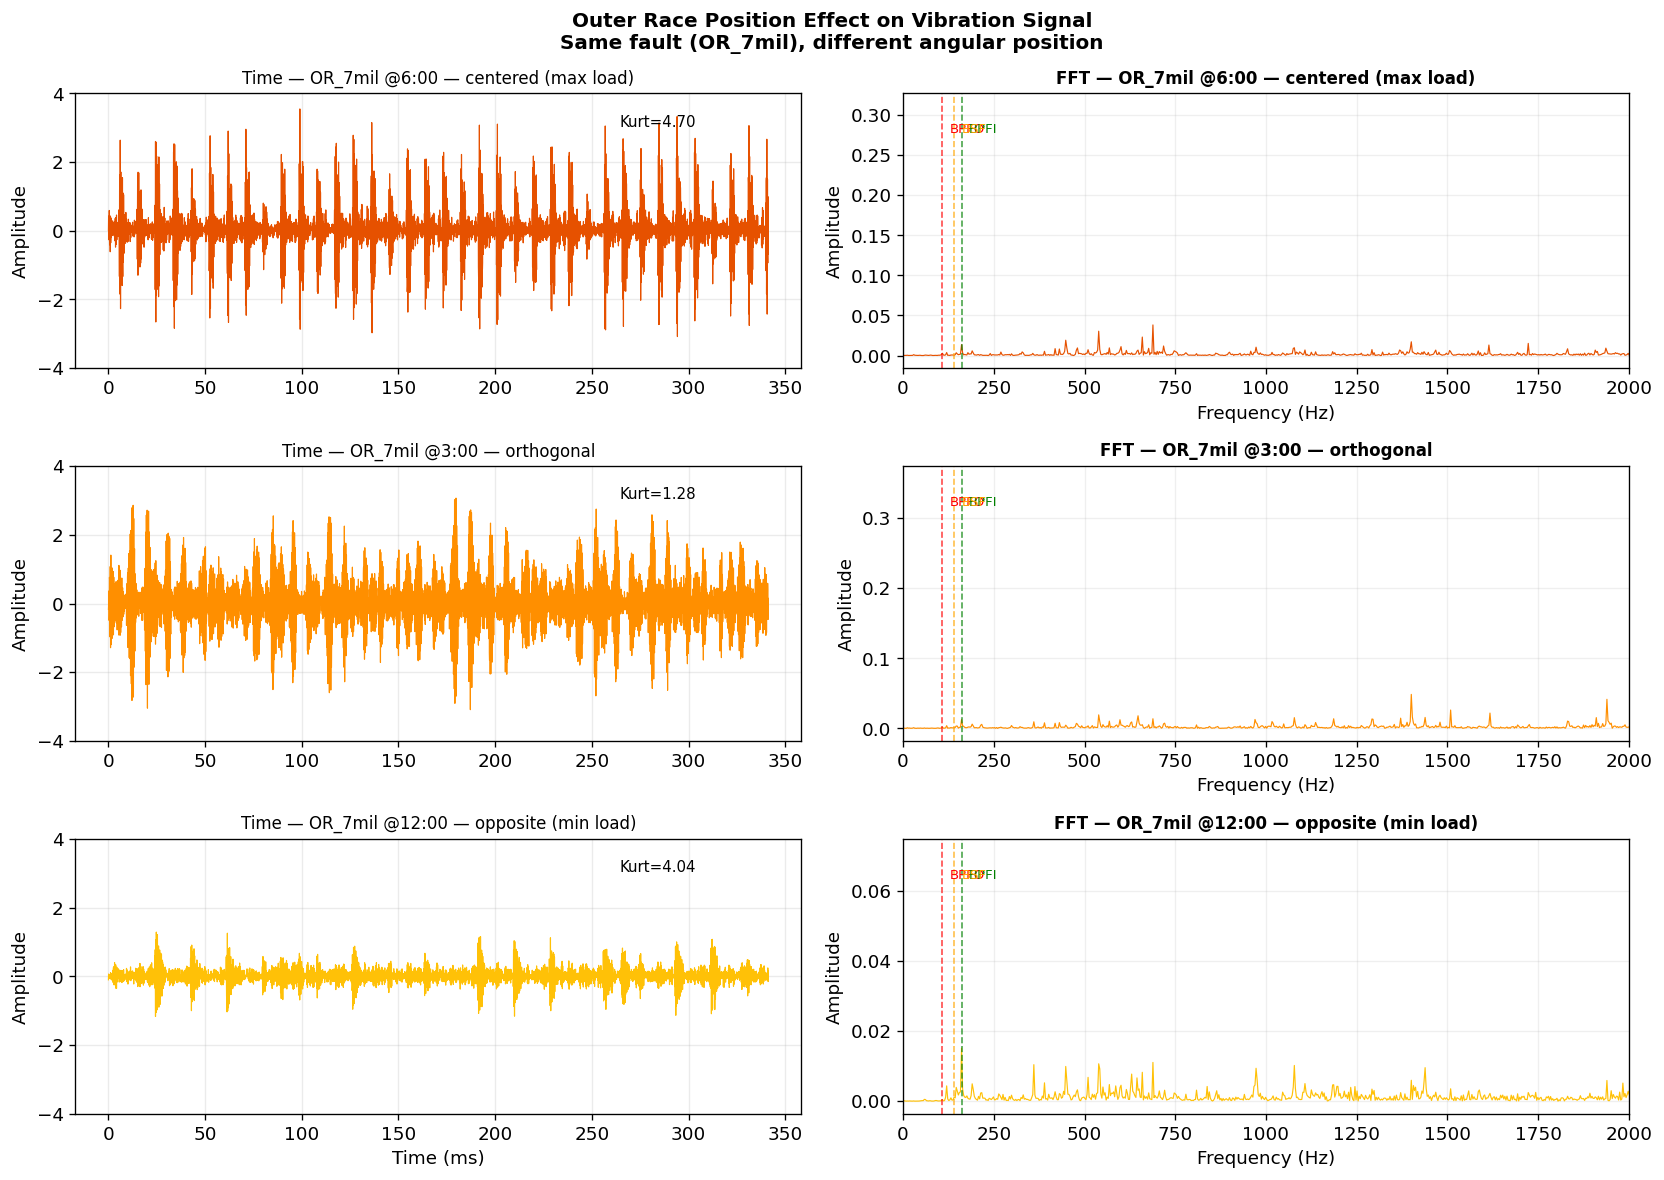

Saved: 03_or_position_comparison.png

Note: OR@6 (max load zone) produces strongest impulses — highest kurtosis
      OR@12 (min load zone) produces weakest impulses — hardest to detect


In [6]:
# Show how fault position changes the signal (OR@6 vs OR@3 vs OR@12)
or_positions = [('OR@6','@6:00 — centered (max load)','#E65100'),
                ('OR@3','@3:00 — orthogonal','#FF8F00'),
                ('OR@12','@12:00 — opposite (min load)','#FFC107')]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
n = 4096
t = np.arange(n) / 12000 * 1000

for row_idx, (fl, desc, col) in enumerate(or_positions):
    rec = next((r for r in records if r['fault_loc']==fl
                and r['severity']==7 and r['load_hp']==0
                and r['sample_rate']==12000), None)
    if rec:
        sig = rec['signal'][:n]
        # Time domain
        axes[row_idx][0].plot(t, sig, color=col, linewidth=0.7)
        axes[row_idx][0].set_title(f'Time — OR_7mil {desc}', fontsize=10)
        axes[row_idx][0].set_ylabel('Amplitude')
        axes[row_idx][0].set_ylim(-4,4)
        axes[row_idx][0].grid(True, alpha=0.25)
        axes[row_idx][0].text(0.75, 0.88, f'Kurt={kurtosis(sig):.2f}',
                              transform=axes[row_idx][0].transAxes, fontsize=9)
        # FFT
        plot_fft(axes[row_idx][1], sig, 12000,
                 f'FFT — OR_7mil {desc}', col, xlim=2000)

axes[-1][0].set_xlabel('Time (ms)')
plt.suptitle('Outer Race Position Effect on Vibration Signal\nSame fault (OR_7mil), different angular position',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/03_or_position_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: 03_or_position_comparison.png')
print()
print('Note: OR@6 (max load zone) produces strongest impulses — highest kurtosis')
print('      OR@12 (min load zone) produces weakest impulses — hardest to detect')

## 6. 12k vs 48k Signal Comparison (same fault)

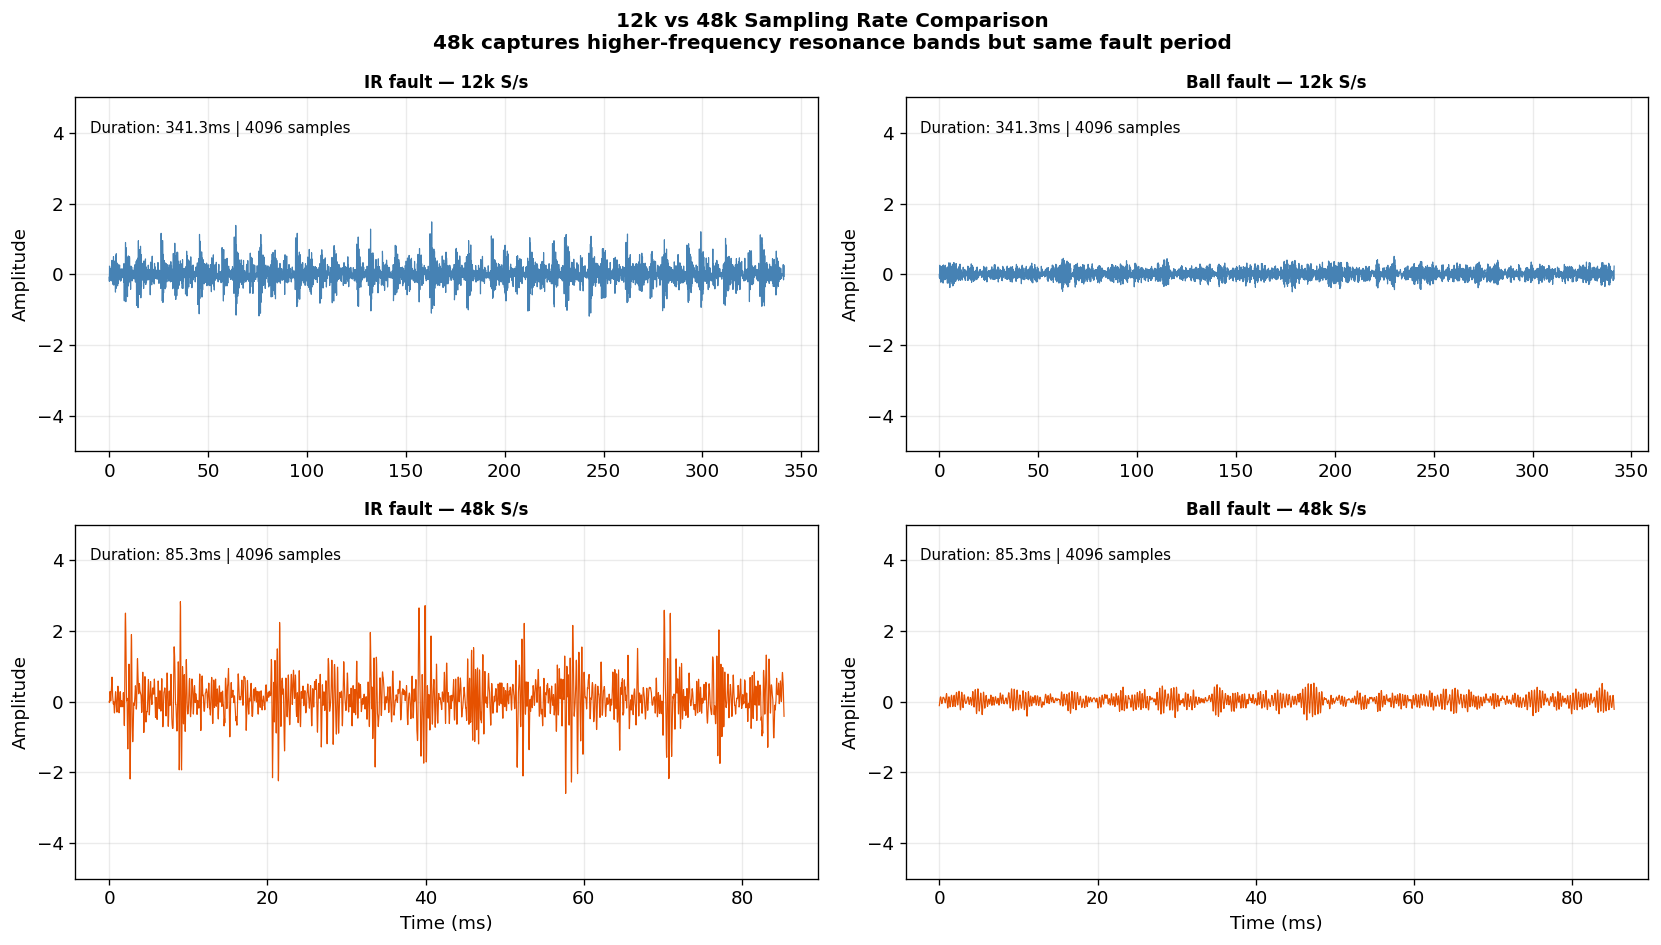

Saved: 04_12k_vs_48k.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
cases = [('IR','IR',7,0),('Ball','Ball',7,0)]

for col_idx, (ft, fl, sv, ld) in enumerate(cases):
    for row_idx, rate in enumerate([12000, 48000]):
        rec = next((r for r in records if r['fault_type']==ft
                    and r['fault_loc']==fl and r['severity']==sv
                    and r['load_hp']==ld and r['sample_rate']==rate), None)
        ax = axes[row_idx][col_idx]
        if rec:
            n   = min(4096, len(rec['signal']))
            sig = rec['signal'][:n]
            t   = np.arange(n) / rate * 1000
            ax.plot(t, sig, linewidth=0.7, color='steelblue' if rate==12000 else '#E65100')
            ax.set_title(f'{ft} fault — {rate//1000}k S/s', fontsize=10, fontweight='bold')
            ax.set_ylabel('Amplitude')
            ax.set_ylim(-5,5)
            ax.grid(True, alpha=0.25)
            ax.text(0.02, 0.9, f'Duration: {n/rate*1000:.1f}ms | {n} samples',
                    transform=ax.transAxes, fontsize=9)
        axes[-1][col_idx].set_xlabel('Time (ms)')

plt.suptitle('12k vs 48k Sampling Rate Comparison\n'
             '48k captures higher-frequency resonance bands but same fault period',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/04_12k_vs_48k.png', bbox_inches='tight')
plt.show()
print('Saved: 04_12k_vs_48k.png')

## 7. Statistical Feature Distributions

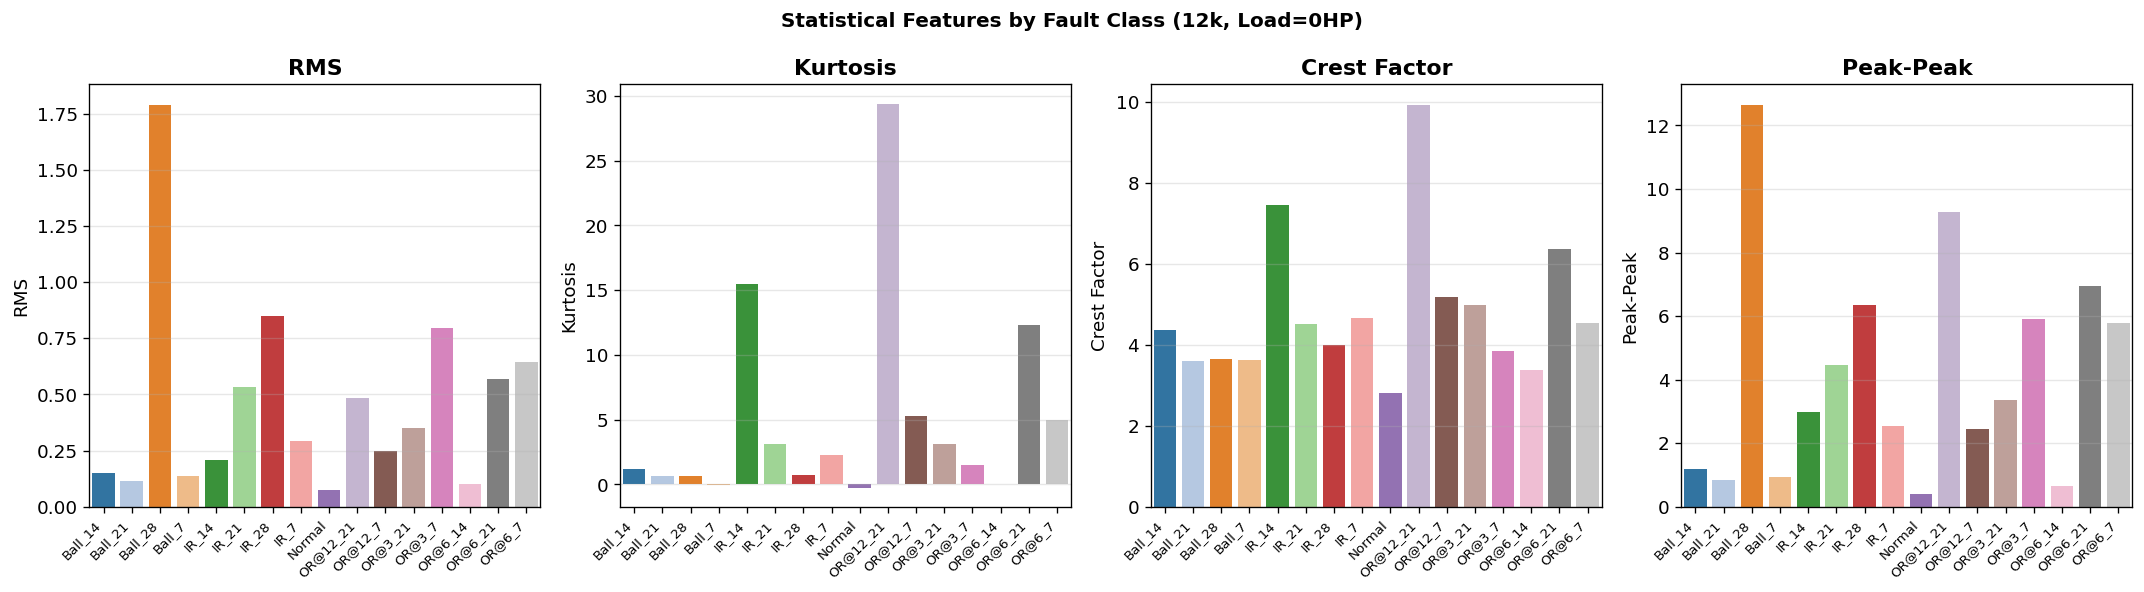

Saved: 05_feature_distributions.png


In [8]:
def stat_features(sig):
    s = sig[:1024]
    s = s - s.mean()
    rms  = np.sqrt(np.mean(s**2))
    peak = np.max(np.abs(s))
    return {
        'RMS':          rms,
        'Kurtosis':     kurtosis(s),
        'Crest Factor': peak / (rms + 1e-8),
        'Peak-Peak':    np.ptp(s)
    }

feat_rows = []
for r in records:
    if r['load_hp'] == 0 and r['sample_rate'] == 12000:
        f = stat_features(r['signal'])
        f['fault_loc'] = r['fault_loc']
        f['severity']  = r['severity']
        feat_rows.append(f)

df_feat = pd.DataFrame(feat_rows)
df_feat['label'] = df_feat.apply(
    lambda x: 'Normal' if x['fault_loc']=='Normal'
              else f"{x['fault_loc']}_{int(x['severity'])}", axis=1)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
order = sorted(df_feat['label'].unique())
palette = sns.color_palette('tab20', n_colors=len(order))

for ax, feat in zip(axes, ['RMS','Kurtosis','Crest Factor','Peak-Peak']):
    sns.barplot(data=df_feat, x='label', y=feat, order=order, palette=palette, ax=ax)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Statistical Features by Fault Class (12k, Load=0HP)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/05_feature_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: 05_feature_distributions.png')

## 8. Severity Comparison — 7 / 14 / 21 mils per fault type

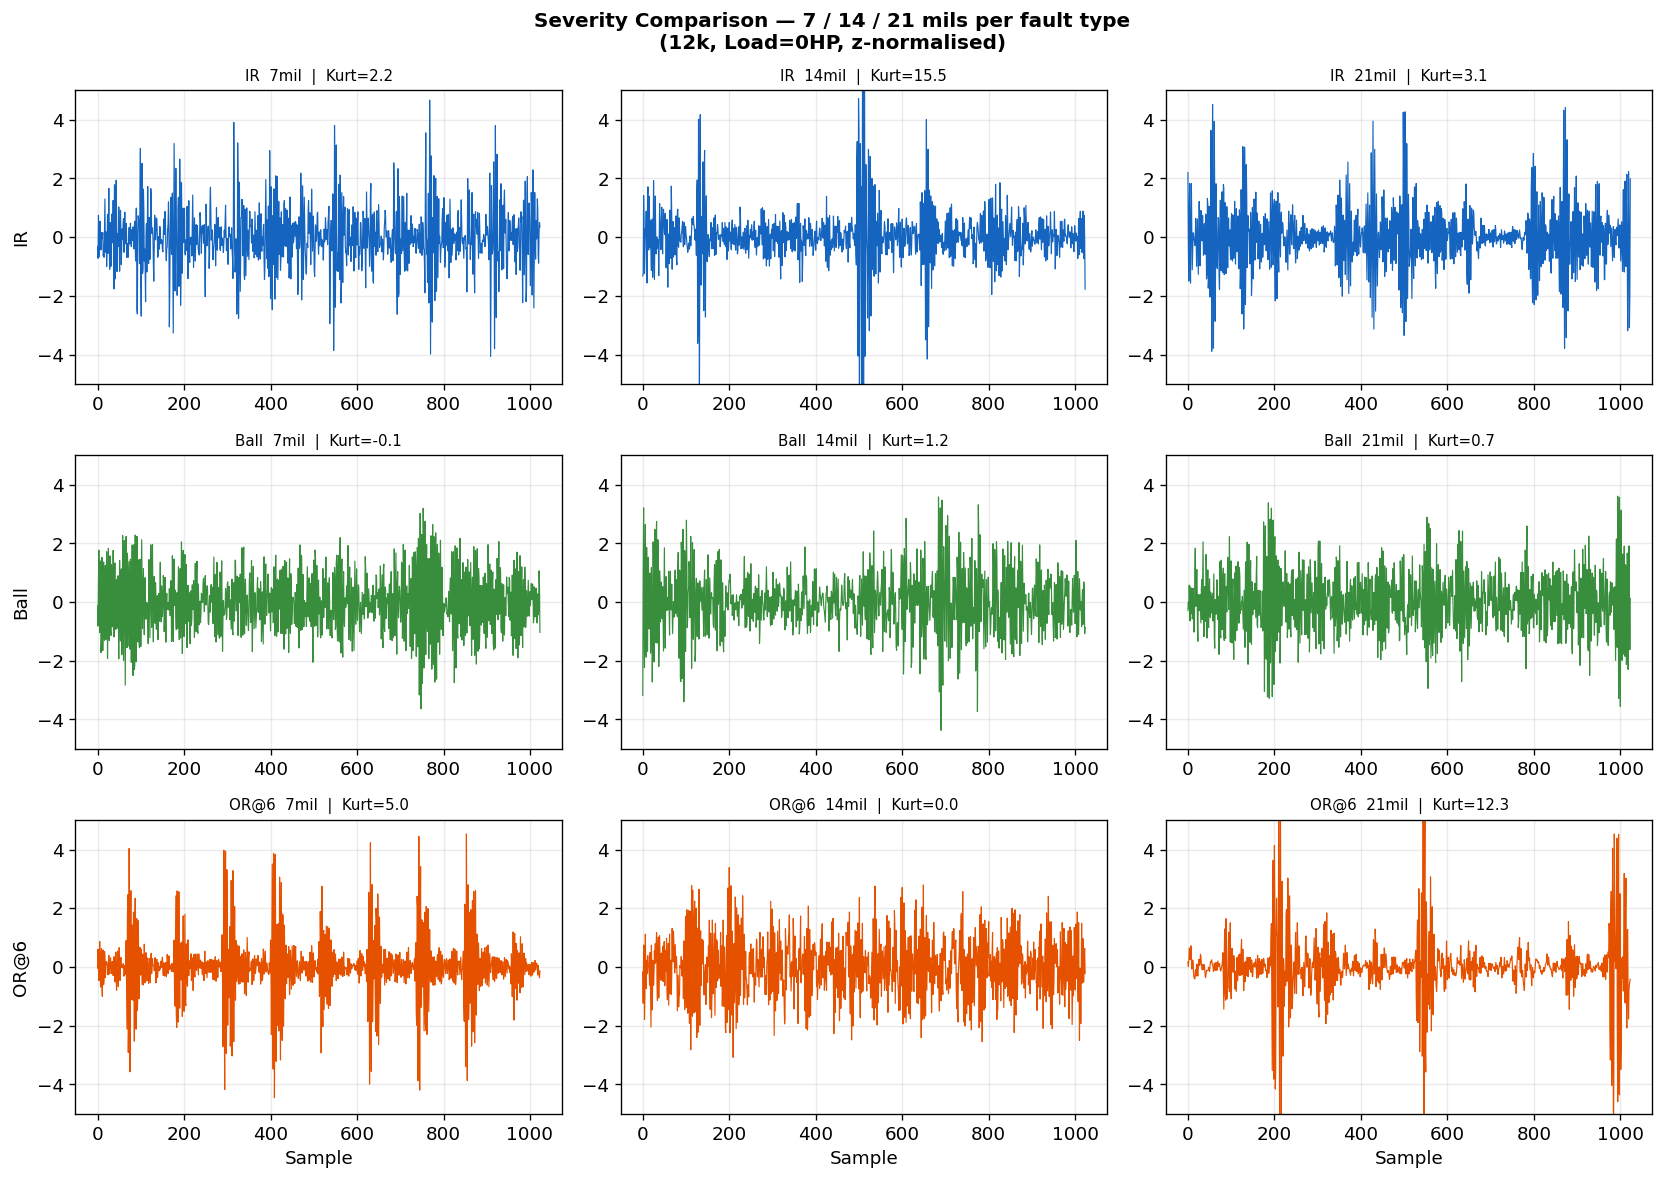

Saved: 06_severity_grid.png


In [9]:
fault_types  = ['IR','Ball','OR@6']
severities   = [7, 14, 21]
colors       = ['#1565C0','#388E3C','#E65100']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
n = 1024

for i, ft in enumerate(fault_types):
    for j, sv in enumerate(severities):
        ax = axes[i][j]
        rec = next((r for r in records if r['fault_loc']==ft
                    and r['severity']==sv and r['load_hp']==0
                    and r['sample_rate']==12000), None)
        if rec:
            sig = rec['signal'][:n]
            sig_norm = (sig - sig.mean()) / (sig.std() + 1e-8)
            ax.plot(sig_norm, linewidth=0.7, color=colors[i])
            ax.set_title(f'{ft}  {sv}mil  |  Kurt={kurtosis(sig_norm):.1f}', fontsize=9)
        ax.set_ylim(-5, 5)
        ax.grid(True, alpha=0.25)
        if i == 2: ax.set_xlabel('Sample')
        if j == 0: ax.set_ylabel(ft)

plt.suptitle('Severity Comparison — 7 / 14 / 21 mils per fault type\n(12k, Load=0HP, z-normalised)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/06_severity_grid.png', bbox_inches='tight')
plt.show()
print('Saved: 06_severity_grid.png')

## 9. Clean & Save Segmented Data

Segments signals into windows, assigns labels, saves to `.npz` for Notebook 3.

In [10]:
WINDOW  = 1024
OVERLAP = 0.5
STEP    = int(WINDOW * (1 - OVERLAP))

# Label scheme: fault_loc + severity (Normal = 0 severity)
# 12k label set  — 10 core classes used in main experiments
LABELS_12K = ['Normal',
               'IR_7','IR_14','IR_21',
               'OR@6_7','OR@6_14','OR@6_21',
               'OR@3_7','OR@3_21',
               'OR@12_7','OR@12_21',
               'Ball_7','Ball_14','Ball_21',
               'IR_28','Ball_28']

label2idx_12k = {l: i for i, l in enumerate(LABELS_12K)}

def make_label(row):
    if row['fault_type'] == 'Normal':
        return 'Normal'
    return f"{row['fault_loc']}_{int(row['severity'])}"

def segment_and_normalise(sig, window, step):
    segs = []
    for start in range(0, len(sig) - window + 1, step):
        s = sig[start:start+window].copy()
        s = (s - s.mean()) / (s.std() + 1e-8)
        segs.append(s.astype(np.float32))
    return segs

def build_dataset(records_subset, label_map):
    X, y, meta = [], [], []
    for r in records_subset:
        lbl = make_label(r)
        if lbl not in label_map:
            continue
        segs = segment_and_normalise(r['signal'], WINDOW, STEP)
        for s in segs:
            X.append(s)
            y.append(label_map[lbl])
            meta.append({'label': lbl, 'load_hp': r['load_hp'],
                         'severity': r['severity'], 'fault_loc': r['fault_loc']})
    return np.array(X), np.array(y), pd.DataFrame(meta)

# ── Build 12k dataset ────────────────────────────────────────────────────────
records_12k = [r for r in records if r['sample_rate'] == 12000]
X_12k, y_12k, meta_12k = build_dataset(records_12k, label2idx_12k)

np.savez_compressed('cwru_segments_12k.npz',
                    X=X_12k, y=y_12k,
                    labels=np.array(LABELS_12K))
meta_12k.to_csv('cwru_meta_12k.csv', index=False)

print(f'12k dataset: X={X_12k.shape}  y={y_12k.shape}')
print(f'Classes ({len(LABELS_12K)}):')
unique, counts = np.unique(y_12k, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {LABELS_12K[u]:16s}: {c:5d} segments')

12k dataset: X=(17503, 1024)  y=(17503,)
Classes (16):
  Normal          :  3310 segments
  IR_7            :   948 segments
  IR_14           :   944 segments
  IR_21           :   946 segments
  OR@6_7          :   949 segments
  OR@6_14         :   946 segments
  OR@6_21         :   949 segments
  OR@3_7          :   946 segments
  OR@3_21         :   947 segments
  OR@12_7         :   948 segments
  OR@12_21        :   948 segments
  Ball_7          :   946 segments
  Ball_14         :   947 segments
  Ball_21         :   947 segments
  IR_28           :   942 segments
  Ball_28         :   940 segments


In [11]:
# ── Build 48k dataset ────────────────────────────────────────────────────────
LABELS_48K = ['Normal',
               'IR_7','IR_14','IR_21',
               'OR@6_7','OR@6_14','OR@6_21',
               'OR@3_7','OR@3_21',
               'OR@12_7','OR@12_21',
               'Ball_7','Ball_14','Ball_21']

label2idx_48k = {l: i for i, l in enumerate(LABELS_48K)}

# 48k uses a larger window to capture the same time duration
WINDOW_48K = 4096   # ~85ms — same duration as 1024@12k
STEP_48K   = int(WINDOW_48K * 0.5)

records_48k = [r for r in records if r['sample_rate'] == 48000]

def segment_48k(sig):
    segs = []
    for start in range(0, len(sig) - WINDOW_48K + 1, STEP_48K):
        s = sig[start:start+WINDOW_48K].copy()
        s = (s - s.mean()) / (s.std() + 1e-8)
        segs.append(s.astype(np.float32))
    return segs

X48, y48, meta48 = [], [], []
for r in records_48k:
    lbl = make_label(r)
    if lbl not in label2idx_48k:
        continue
    for s in segment_48k(r['signal']):
        X48.append(s)
        y48.append(label2idx_48k[lbl])
        meta48.append({'label':lbl,'load_hp':r['load_hp'],'severity':r['severity']})

X_48k = np.array(X48)
y_48k = np.array(y48)

np.savez_compressed('cwru_segments_48k.npz',
                    X=X_48k, y=y_48k,
                    labels=np.array(LABELS_48K))
pd.DataFrame(meta48).to_csv('cwru_meta_48k.csv', index=False)

print(f'48k dataset: X={X_48k.shape}  y={y_48k.shape}')
print(f'\nAll EDA plots saved to: {PLOTS_DIR}/')
print('Cleaned datasets saved:')
print('  cwru_segments_12k.npz  + cwru_meta_12k.csv')
print('  cwru_segments_48k.npz  + cwru_meta_48k.csv')
print('\n✅ EDA complete. Run 03_ml.ipynb next.')

48k dataset: X=(10428, 4096)  y=(10428,)

All EDA plots saved to: eda_plots/
Cleaned datasets saved:
  cwru_segments_12k.npz  + cwru_meta_12k.csv
  cwru_segments_48k.npz  + cwru_meta_48k.csv

✅ EDA complete. Run 03_ml.ipynb next.
